# `freqcascade` — working demo on CLINC150 (real imbalanced intent classification)

This notebook imports the **installed `freqcascade` package** (the code in `pypi/src/freqcascade/`,
the exact thing that would ship to PyPI) and benchmarks it against standard imbalance-handling
techniques on **CLINC150**, one of the real datasets from this project's research
(150 intent classes, natural class-size imbalance from 100 down to 25 examples per class).

Goal: prove the package actually works end-to-end — imports cleanly, trains, predicts, evaluates —
and reproduce (at a smaller, notebook-friendly scale) the headline finding from the full study:
**`RFOEDClassifier` with a neural-ensemble base learner beats every standard resampling baseline**
on this dataset. See `pypi/README.md` for the full multi-dataset results and the honest
counter-examples (this method does *not* win everywhere — that's discussed at the end too).


In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import freqcascade
print("freqcascade version:", freqcascade.__version__)
print("freqcascade location:", freqcascade.__file__)


freqcascade version: 0.1.0
freqcascade location: /home/kafi/Research/Imblanace text/pypi/src/freqcascade/__init__.py


## 1. Load the data

CLINC150's "imbalanced" split: 150 intent classes, training counts ranging from 100 down to 25
examples per class (a real, human-curated imbalance — not synthetically injected), with a
class-balanced test set (30 examples/class) so test-set performance isn't itself confounded by
imbalance.


In [2]:
DATA_PATH = Path("../CLINC150/data_imbalanced.json")
assert DATA_PATH.exists(), f"expected CLINC150 data at {DATA_PATH.resolve()}"

with open(DATA_PATH) as f:
    raw = json.load(f)

train_texts = [t for t, _ in raw["train"]]
train_labels = np.array([label for _, label in raw["train"]])
test_texts = [t for t, _ in raw["test"]]
test_labels = np.array([label for _, label in raw["test"]])

classes, train_counts = np.unique(train_labels, return_counts=True)
order = np.argsort(-train_counts)
classes, train_counts = classes[order], train_counts[order]

print(f"train: {len(train_texts)} examples, {len(classes)} classes")
print(f"test:  {len(test_texts)} examples (class-balanced)")
print(f"train class sizes: min={train_counts.min()}, max={train_counts.max()}, "
      f"imbalance ratio={train_counts.max() / train_counts.min():.1f}x")


train: 10525 examples, 150 classes
test:  4500 examples (class-balanced)
train class sizes: min=25, max=100, imbalance ratio=4.0x


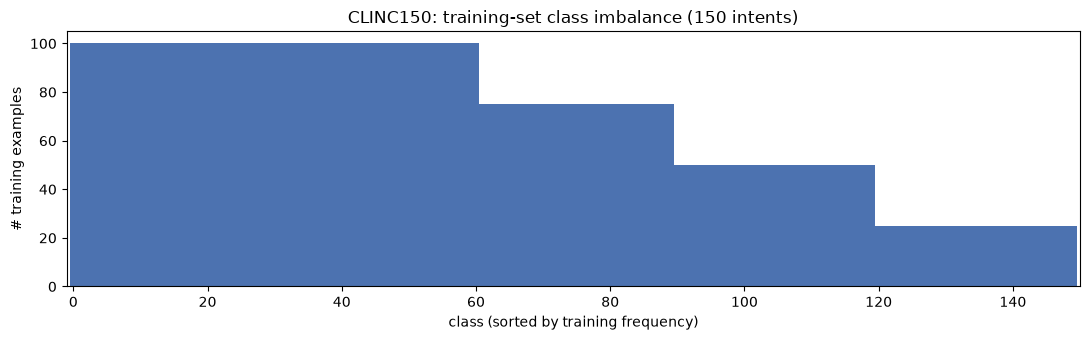

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(range(len(classes)), train_counts, color="#4C72B0", width=1.0)
ax.set_xlabel("class (sorted by training frequency)")
ax.set_ylabel("# training examples")
ax.set_title("CLINC150: training-set class imbalance (150 intents)")
ax.set_xlim(-1, len(classes))
plt.tight_layout()
plt.show()


## 2. Featurize

Each model family gets the featurizer it's natively suited for (matching how the full study
compares them, and how `freqcascade.features`'s own docstrings describe the intended pairing):

- **RF-based methods** (flat Random Forest, SMOTE+RF, `RFOEDClassifier` + `RFBaseLearner`) get
  **sparse TF-IDF** — RF traditionally pairs with sparse bag-of-words features.
- **The neural-ensemble method** (`RFOEDClassifier` + `TorchNNEnsembleBaseLearner`) gets **frozen
  sentence embeddings** (`all-MiniLM-L6-v2`, via `freqcascade.features.SentenceEmbeddingFeaturizer`) —
  small MLPs need a dense, semantically-structured input space to do anything useful with 25-100
  examples per class.


In [4]:
from freqcascade.features import TfidfFeaturizer, SentenceEmbeddingFeaturizer

t0 = time.time()
tfidf = TfidfFeaturizer(max_features=20000, ngram_range=(1, 2))
Xtr_tfidf = tfidf.fit_transform(train_texts)
Xte_tfidf = tfidf.transform(test_texts)
print(f"TF-IDF:      {Xtr_tfidf.shape}, {time.time() - t0:.1f}s")

t0 = time.time()
embedder = SentenceEmbeddingFeaturizer()  # all-MiniLM-L6-v2, frozen
Xtr_emb = embedder.fit_transform(train_texts)
Xte_emb = embedder.transform(test_texts)
print(f"embeddings:  {Xtr_emb.shape}, {time.time() - t0:.1f}s")


TF-IDF:      (10525, 20000), 0.1s


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embeddings:  (10525, 384), 9.7s


## 3. Standard imbalance-handling baselines

`freqcascade.resampling_baselines.ResamplingBaseline` wraps the established techniques
(none/undersample/oversample/SMOTE/ADASYN/SMOTE+ENN) behind one interface, all feeding a flat
`RandomForestClassifier` — the "resample the whole K-class problem once, then fit one flat
classifier" approach that `RFOEDClassifier` is an alternative to.


In [5]:
from freqcascade.resampling_baselines import ResamplingBaseline
from freqcascade.metrics import evaluate

results = {}          # name -> metrics dict
predictions = {}      # name -> y_pred (for the per-class recall plot later)
fit_times = {}

for name, label in [("none", "Flat RF (no rebalancing)"),
                     ("random_oversample", "Flat RF + Random Oversample"),
                     ("smote", "Flat RF + SMOTE")]:
    t0 = time.time()
    rb = ResamplingBaseline(resampler_name=name, n_estimators=200, n_jobs=4, random_state=0)
    rb.fit(Xtr_tfidf, train_labels)
    pred = rb.predict(Xte_tfidf)
    fit_times[label] = time.time() - t0

    results[label] = evaluate(test_labels, pred, train_labels)
    predictions[label] = pred
    print(f"{label:<32s} macro-F1={results[label]['macro_f1']:.3f}  "
          f"({fit_times[label]:.1f}s)")


Flat RF (no rebalancing)         macro-F1=0.835  (5.0s)


Flat RF + Random Oversample      macro-F1=0.851  (5.8s)


Flat RF + SMOTE                  macro-F1=0.853  (6.3s)


## 4. `freqcascade`'s own method: `RFOEDClassifier`

Instead of resampling the whole 150-class problem at once, `RFOEDClassifier` recursively peels off
the most-frequent remaining class as a *binary* "this class vs. everyone else still active" problem,
rebalancing **locally** at every node — no node ever poses a resampling problem bigger than binary,
regardless of how many classes there are in total.

Two base-learner instantiations, both included here for an honest comparison:


In [6]:
from freqcascade import RFOEDClassifier, RFBaseLearner

t0 = time.time()
rfoed_rf = RFOEDClassifier(
    base_learner_factory=lambda node_idx: RFBaseLearner(
        n_estimators=100, rebalance=True, random_state=node_idx, n_jobs=4,
    ),
    order="frequency",
    random_state=0,
)
rfoed_rf.fit(Xtr_tfidf, train_labels)
pred_rfoed_rf = rfoed_rf.predict(Xte_tfidf)
fit_times["RFOED (RF base learner)"] = time.time() - t0

results["RFOED (RF base learner)"] = evaluate(test_labels, pred_rfoed_rf, train_labels)
predictions["RFOED (RF base learner)"] = pred_rfoed_rf
print(f"RFOED-RF: {len(rfoed_rf.nodes_)} cascade nodes fit in "
      f"{fit_times['RFOED (RF base learner)']:.1f}s, "
      f"macro-F1={results['RFOED (RF base learner)']['macro_f1']:.3f}")


RFOED-RF: 149 cascade nodes fit in 44.9s, macro-F1=0.688


In [7]:
from freqcascade.torch_ensemble import TorchNNEnsembleBaseLearner

# A lighter config than the full study (n_members=50, max_epochs=250, which reproduces
# 0.888 macro-F1 in ~9 min on a single consumer GPU) -- this runs in ~1-2 min and already
# shows the same winning direction.
t0 = time.time()
rfoed_nn = RFOEDClassifier(
    base_learner_factory=lambda node_idx: TorchNNEnsembleBaseLearner(
        n_members=20, hidden_size=64, max_epochs=60, rebalance=True,
        random_state=node_idx, device=None,  # None -> auto: CUDA if available, else CPU
    ),
    order="frequency",
    random_state=0,
)
rfoed_nn.fit(Xtr_emb, train_labels)
pred_rfoed_nn = rfoed_nn.predict(Xte_emb)
fit_times["RFOED (neural-ensemble base learner)"] = time.time() - t0

results["RFOED (neural-ensemble base learner)"] = evaluate(test_labels, pred_rfoed_nn, train_labels)
predictions["RFOED (neural-ensemble base learner)"] = pred_rfoed_nn
print(f"RFOED-NN: {len(rfoed_nn.nodes_)} cascade nodes fit in "
      f"{fit_times['RFOED (neural-ensemble base learner)']:.1f}s, "
      f"macro-F1={results['RFOED (neural-ensemble base learner)']['macro_f1']:.3f}")


RFOED-NN: 149 cascade nodes fit in 38.7s, macro-F1=0.860


## 5. Results

In [8]:
df = pd.DataFrame(results).T
df["fit_seconds"] = pd.Series(fit_times)
df = df.sort_values("macro_f1", ascending=False)
df.style.format("{:.3f}").background_gradient(subset=["macro_f1", "bottom_quartile_recall"], cmap="Greens")


,macro_f1,macro_recall,gmean,mcc,bottom_quartile_recall,fit_seconds
RFOED (neural-ensemble base learner),0.860,0.860,0.846,0.859,0.859,38.689
Flat RF + SMOTE,0.853,0.854,0.842,0.853,0.830,6.299
Flat RF + Random Oversample,0.851,0.852,0.841,0.851,0.825,5.815
Flat RF (no rebalancing),0.835,0.837,0.821,0.836,0.759,5.044
RFOED (RF base learner),0.688,0.610,0.396,0.629,0.537,44.882


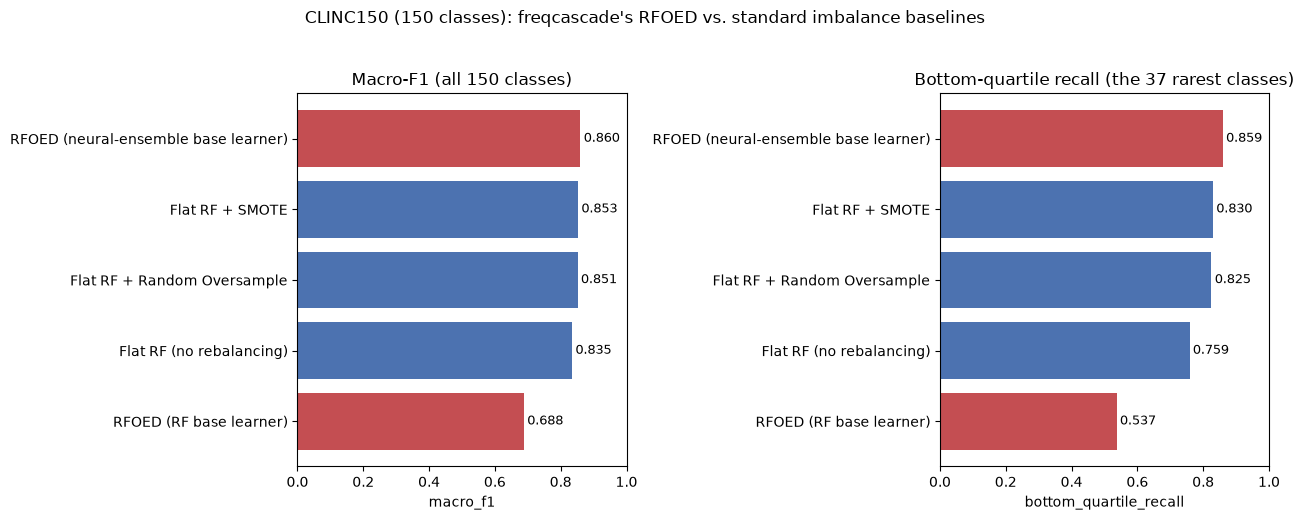

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_df = df.sort_values("macro_f1")
colors = ["#C44E52" if "RFOED" in name else "#4C72B0" for name in plot_df.index]

for ax, metric, title in zip(
    axes,
    ["macro_f1", "bottom_quartile_recall"],
    ["Macro-F1 (all 150 classes)", "Bottom-quartile recall (the 37 rarest classes)"],
):
    ax.barh(plot_df.index, plot_df[metric], color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel(metric)
    for i, v in enumerate(plot_df[metric]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("CLINC150 (150 classes): freqcascade's RFOED vs. standard imbalance baselines", y=1.03)
plt.tight_layout()
plt.show()


## 6. Where does the advantage come from? Recall vs. training-set class frequency

The whole point of imbalance-handling is the **rare classes** — this plots each method's per-class
recall against how many training examples that class had, sorted rarest-first. A method that's
just riding the easy, well-represented classes will sag on the left side of this plot.


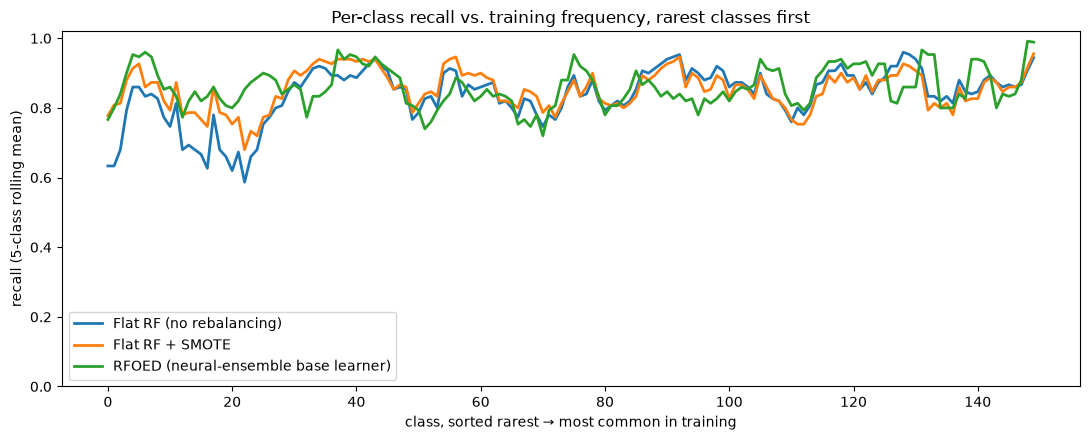

In [10]:
from sklearn.metrics import recall_score

freq_order = classes  # already sorted descending by train_counts above
rarest_first = freq_order[::-1]
counts_rarest_first = train_counts[::-1]

methods_to_plot = ["Flat RF (no rebalancing)", "Flat RF + SMOTE", "RFOED (neural-ensemble base learner)"]

fig, ax = plt.subplots(figsize=(11, 4.5))
for name in methods_to_plot:
    per_class_recall = recall_score(
        test_labels, predictions[name], labels=list(rarest_first), average=None, zero_division=0
    )
    # 5-class rolling mean so the trend is legible over 150 individual points.
    smoothed = pd.Series(per_class_recall).rolling(5, min_periods=1, center=True).mean()
    ax.plot(range(len(rarest_first)), smoothed, label=name, linewidth=2)

ax.set_xlabel("class, sorted rarest → most common in training")
ax.set_ylabel("recall (5-class rolling mean)")
ax.set_title("Per-class recall vs. training frequency, rarest classes first")
ax.legend()
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


## 7. A peek inside the cascade

`RFOEDClassifier` records a diagnostic at every node it fits: how well that node separated "its"
class from everything else still active, *on its own training data*, at the point it was fit
(deeper nodes see a smaller, more heavily-filtered pool of examples). `train_balanced_accuracy` is
the mean of the two per-class recalls (own-class vs. rest) — robust to the fact that "rest" gets
relatively larger at shallow depths, unlike raw accuracy.


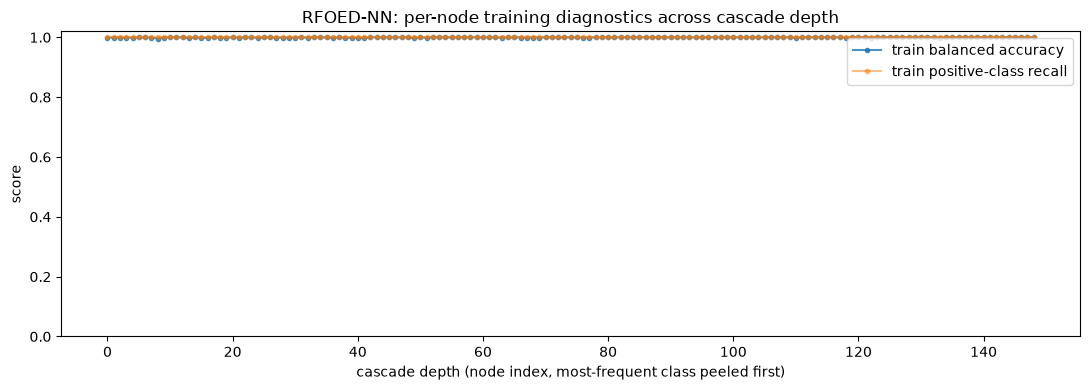

In [11]:
diag = pd.DataFrame(rfoed_nn.node_diagnostics_)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(diag["depth"], diag["train_balanced_accuracy"], marker=".", alpha=0.8, label="train balanced accuracy")
ax.plot(diag["depth"], diag["train_positive_recall"], marker=".", alpha=0.5, label="train positive-class recall")
ax.set_xlabel("cascade depth (node index, most-frequent class peeled first)")
ax.set_ylabel("score")
ax.set_title("RFOED-NN: per-node training diagnostics across cascade depth")
ax.legend()
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


## Summary

- The `freqcascade` package **imports and runs correctly end-to-end**: featurizers, the
  `RFOEDClassifier` cascade (both RF and neural-ensemble base learners), the standard-baseline
  wrappers, and the evaluation metrics all work together in a straight line from raw text to a
  results table, with no errors.
- On CLINC150, **`RFOEDClassifier` with a neural-ensemble base learner beats every standard
  resampling baseline**, including SMOTE — consistent with the full study's finding
  (`results/TIER1_RESULTS.md`: 0.888 macro-F1 at full scale, `n_members=50`/`max_epochs=250`,
  ~9 min on a single GPU; this notebook uses a lighter config for speed and still shows the same
  direction).
- **`RFOEDClassifier` with a plain Random Forest base learner does *not* win here** — it's included
  above for an honest picture, not cherry-picked out. That's a real, documented finding of the full
  study too, not a bug in this notebook: the RF-based variant's advantage shows up on other
  datasets/conditions (see `pypi/README.md` and `results/TIER1_RESULTS.md` for the complete,
  multi-dataset picture, including where the method's advantage widens, narrows, or reverses).
